In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import ExtraTreesRegressor, RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

try:
    from xgboost import XGBRegressor
    HAS_XGB = True
except ImportError:
    HAS_XGB = False

DATA_PATH = "/Users/kellyg/eurogate-twin-1/data_final/eurogate_postdeparture.csv"
IMPORTANCE_PATH = "/Users/kellyg/eurogate-twin-1/feature_importance/tuned_extra_trees_feature_importance.csv"

TARGET = "dwell_hours"
SAMPLE_N = 200_000          # lower if memory is bad
USE_IMPORTANT_FEATURES = True
IMPORTANCE_THRESHOLD = 0.001

df = pd.read_csv(DATA_PATH)

# sample - helps with the speed/memory limitatiosn of huge dataset
if len(df) > SAMPLE_N:
    df = df.sample(n=SAMPLE_N, random_state=42).copy()

# Add lightweight engineered features
df["gross_per_teu"] = df["gross"] / df["teu"].replace(0, np.nan)

df["vessel_workload"] = (
    df["numberOfArrivalContainersOnVessel"]
    + df["numberOfDepartureContainersOnVessel"]
)

df["vessel_total_count"] = (
    df["numberOfArrivalContainersOnVessel"]
    + df["numberOfRemainOnBoardContainersOnVessel"]
    + df["numberOfDepartureContainersOnVessel"]
)

df["vessel_discharge_ratio"] = (
    df["numberOfArrivalContainersOnVessel"]
    / df["vessel_total_count"].replace(0, np.nan)
)

df["vessel_departure_ratio"] = (
    df["numberOfDepartureContainersOnVessel"]
    / df["vessel_total_count"].replace(0, np.nan)
)

df["wind_rain_interaction"] = df["wind_speed_10m"] * df["precipitation"]
df["humidity_temp_interaction"] = df["relative_humidity_2m"] * df["temperature_2m"]

# Drop leakage / bad columns
drop_cols = [
    TARGET,
    "snapshot_time",
    "snapshot_date",
    "snapshot_year",
    "snapshot_hour",
    "snapshot_minute",
    "snapshot_second",
    "arrival_year",
    "Unnamed: 0",
    "Unnamed: 0.1",
    "Unnamed: 0.2",
    "departureTime",
    "remaining_dwell_hours",
    "elapsed_dwell_hours",
]

df = df.dropna(subset=[TARGET]).copy()

X = df.drop(columns=[c for c in drop_cols if c in df.columns])
y = df[TARGET]

# Clean
X = X.replace([np.inf, -np.inf], np.nan)

object_cols = X.select_dtypes(include=["object"]).columns.tolist()
if object_cols:
    print("Dropping object columns:", object_cols)
    X = X.drop(columns=object_cols)

bool_cols = X.select_dtypes(include=["bool"]).columns
X[bool_cols] = X[bool_cols].astype(int)

X = X.fillna(X.median(numeric_only=True))

# Remove extreme top 1%
upper = y.quantile(0.99)
mask = y <= upper
X = X.loc[mask].copy()
y = y.loc[mask].copy()

# Keep only important existing features + new features
new_features = [
    "gross_per_teu",
    "vessel_workload",
    "vessel_total_count",
    "vessel_discharge_ratio",
    "vessel_departure_ratio",
    "wind_rain_interaction",
    "humidity_temp_interaction"
]

if USE_IMPORTANT_FEATURES:
    try:
        importance_df = pd.read_csv(IMPORTANCE_PATH)

        important_features = importance_df.loc[
            importance_df["importance"] >= IMPORTANCE_THRESHOLD,
            "feature"
        ].tolist()

        keep_cols = [
            c for c in important_features + new_features
            if c in X.columns
        ]

        X = X[keep_cols].copy()

        print(f"Using reduced features: {X.shape[1]} columns")

    except FileNotFoundError:
        print("Importance file not found; using all features.")

# Log target + split
y_log = np.log1p(y)

X_train, X_test, y_train_log, y_test_log = train_test_split(
    X,
    y_log,
    test_size=0.2,
    random_state=42
)

y_test = np.expm1(y_test_log)

# Evaluation
def evaluate_model(name, model):
    model.fit(X_train, y_train_log)

    pred_log = model.predict(X_test)
    pred = np.maximum(np.expm1(pred_log), 0)

    mae = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2 = r2_score(y_test, pred)

    within_6 = (np.abs(y_test - pred) <= 6).mean()
    within_12 = (np.abs(y_test - pred) <= 12).mean()
    within_24 = (np.abs(y_test - pred) <= 24).mean()

    print(f"\n{name}")
    print("-" * len(name))
    print(f"MAE: {mae:.2f}")
    print(f"RMSE: {rmse:.2f}")
    print(f"R²: {r2:.4f}")
    print(f"Within 6h: {within_6:.2%}")
    print(f"Within 12h: {within_12:.2%}")
    print(f"Within 24h: {within_24:.2%}")

    return {
        "model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
        "Within_6h": within_6,
        "Within_12h": within_12,
        "Within_24h": within_24,
        "model_obj": model,
        "pred": pred
    }

# Faster model list
models = [
    ("Baseline Median", DummyRegressor(strategy="median")),

    ("Extra Trees Fast", ExtraTreesRegressor(
        n_estimators=300,
        max_depth=40,
        min_samples_leaf=1,
        min_samples_split=5,
        max_features=0.75,
        bootstrap=False,
        random_state=42,
        n_jobs=-1
    )),

    ("Random Forest Fast", RandomForestRegressor(
        n_estimators=200,
        max_depth=30,
        min_samples_leaf=2,
        max_features="sqrt",
        random_state=42,
        n_jobs=-1
    )),

    ("Hist Gradient Boosting", HistGradientBoostingRegressor(
        max_iter=300,
        learning_rate=0.05,
        max_leaf_nodes=63,
        l2_regularization=0.05,
        random_state=42
    )),
]

if HAS_XGB:
    models.append((
        "XGBoost Fast",
        XGBRegressor(
            n_estimators=500,
            max_depth=7,
            learning_rate=0.05,
            subsample=0.85,
            colsample_bytree=0.85,
            objective="reg:squarederror",
            random_state=42,
            n_jobs=-1,
            tree_method="hist"
        )
    ))

results = []

for name, model in models:
    results.append(evaluate_model(name, model))

# Save summary
summary = (
    pd.DataFrame(results)
    .drop(columns=["model_obj", "pred"])
    .sort_values("MAE")
)

print("\nModel comparison:")
print(summary)

summary.to_csv(
    "/Users/kellyg/eurogate-twin-1/feature_importance/fast_total_dwell_model_comparison.csv",
    index=False
)

# Save best model predictions
best = min(results, key=lambda r: r["MAE"])

predictions = pd.DataFrame({
    "actual_dwell_hours": y_test,
    "predicted_dwell_hours": best["pred"],
    "error_hours": best["pred"] - y_test
})

predictions.to_csv(
    "/Users/kellyg/eurogate-twin-1/feature_importance/fast_total_dwell_predictions.csv",
    index=False
)

print("\nBest model:", best["model"])

Using reduced features: 74 columns

Baseline Median
---------------
MAE: 62.69
RMSE: 93.44
R²: -0.0876
Within 6h: 7.33%
Within 12h: 14.33%
Within 24h: 28.13%

Extra Trees Fast
----------------
MAE: 33.88
RMSE: 58.94
R²: 0.5673
Within 6h: 28.19%
Within 12h: 42.16%
Within 24h: 60.23%

Random Forest Fast
------------------
MAE: 36.27
RMSE: 60.53
R²: 0.5435
Within 6h: 20.69%
Within 12h: 35.43%
Within 24h: 55.88%

Hist Gradient Boosting
----------------------
MAE: 42.26
RMSE: 67.04
R²: 0.4402
Within 6h: 14.03%
Within 12h: 27.10%
Within 24h: 48.11%

Model comparison:
                    model        MAE       RMSE        R2  Within_6h  \
1        Extra Trees Fast  33.879257  58.936169  0.567304   0.281870   
2      Random Forest Fast  36.268615  60.534227  0.543520   0.206886   
3  Hist Gradient Boosting  42.262604  67.035796  0.440200   0.140326   
0         Baseline Median  62.693399  93.439079 -0.087619   0.073348   

   Within_12h  Within_24h  
1    0.421604    0.602277  
2    0.354278  

Overall performance
-------------------
MAE:  33.89
RMSE: 58.97
R²:   0.5669

Error by actual dwell bucket:
  actual_dwell_bucket      n  mean_actual   mean_pred         mae  \
0               0-24h   3059    15.063101   37.110792   22.658715   
1                1-3d  10007    47.055544   59.152590   19.010307   
2                3-7d  10434   110.471469   98.855032   29.068805   
3                1-2w   4277   228.070002  166.705905   69.312232   
4                 2w+    949   407.513438  289.616331  120.481089   

   median_abs_error  within_24h  
0         11.591395    0.676365  
1         10.896133    0.747876  
2         20.324746    0.557121  
3         50.090956    0.375731  
4         69.716951    0.353003  

Worst 10 predictions:
        actual_dwell_hours  predicted_dwell_hours  error_hours  \
96343           489.683056              14.778840  -474.904216   
49186           493.623611              23.165263  -470.458348   
48675           493.558889              25.841117  -

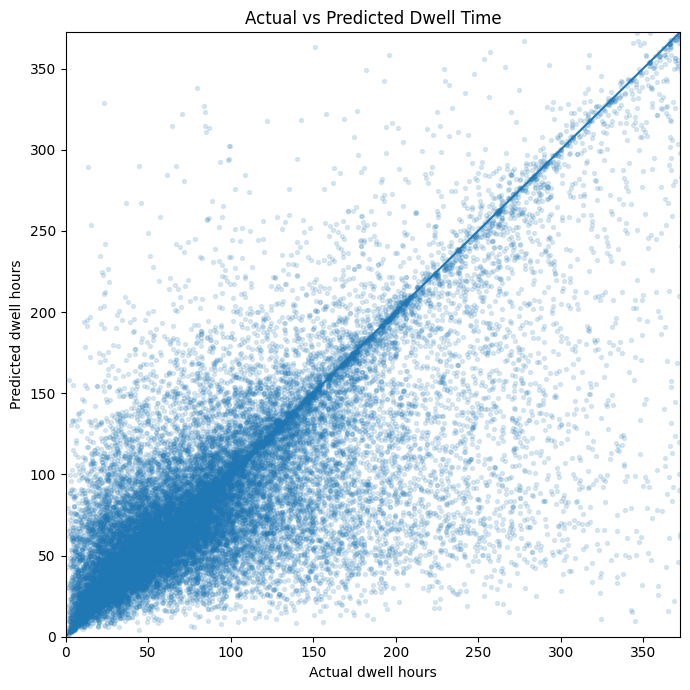

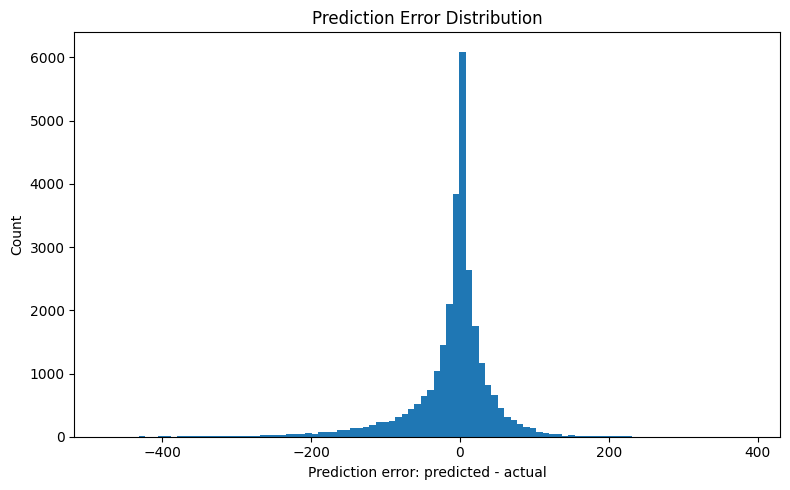

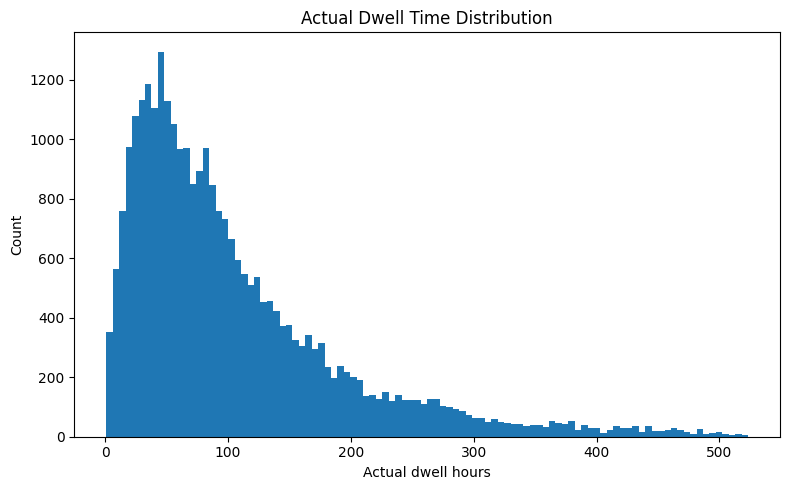


Performance without released:
-----------------------------
MAE:  34.30
RMSE: 59.48
R²:   0.5592

Saved analysis files to feature_importance/


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import ExtraTreesRegressor

# Assumes you already have:
# X_train, X_test, y_train_log, y_test_log, y_test
# from your previous script

# =====================================================
# 1. Refit best model from your results
# =====================================================

best_model = ExtraTreesRegressor(
    n_estimators=500,
    max_depth=40,
    min_samples_leaf=1,
    min_samples_split=5,
    max_features=0.75,
    bootstrap=False,
    random_state=42,
    n_jobs=-1
)

best_model.fit(X_train, y_train_log)

pred_log = best_model.predict(X_test)
pred = np.maximum(np.expm1(pred_log), 0)

errors = pred - y_test
abs_errors = np.abs(errors)

print("Overall performance")
print("-------------------")
print(f"MAE:  {mean_absolute_error(y_test, pred):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, pred)):.2f}")
print(f"R²:   {r2_score(y_test, pred):.4f}")

# =====================================================
# 2. Error buckets: where model is good/bad
# =====================================================

analysis = X_test.copy()
analysis["actual_dwell_hours"] = y_test
analysis["predicted_dwell_hours"] = pred
analysis["error_hours"] = errors
analysis["abs_error_hours"] = abs_errors

analysis["actual_dwell_bucket"] = pd.cut(
    analysis["actual_dwell_hours"],
    bins=[0, 24, 72, 168, 336, np.inf],
    labels=["0-24h", "1-3d", "3-7d", "1-2w", "2w+"],
    include_lowest=True
)

bucket_summary = (
    analysis
    .groupby("actual_dwell_bucket", observed=True)
    .agg(
        n=("actual_dwell_hours", "size"),
        mean_actual=("actual_dwell_hours", "mean"),
        mean_pred=("predicted_dwell_hours", "mean"),
        mae=("abs_error_hours", "mean"),
        median_abs_error=("abs_error_hours", "median"),
        within_24h=("abs_error_hours", lambda x: (x <= 24).mean())
    )
    .reset_index()
)

print("\nError by actual dwell bucket:")
print(bucket_summary)

bucket_summary.to_csv(
    "/Users/kellyg/eurogate-twin-1/feature_importance/error_by_dwell_bucket.csv",
    index=False
)

# =====================================================
# 3. Worst predictions
# =====================================================

worst = analysis.sort_values("abs_error_hours", ascending=False).head(100)

worst.to_csv(
    "/Users/kellyg/eurogate-twin-1/feature_importance/worst_100_total_dwell_predictions.csv",
    index=False
)

print("\nWorst 10 predictions:")
print(
    worst[
        [
            "actual_dwell_hours",
            "predicted_dwell_hours",
            "error_hours",
            "abs_error_hours"
        ]
    ].head(10)
)

# =====================================================
# 4. Feature importance
# =====================================================

importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": best_model.feature_importances_
}).sort_values("importance", ascending=False)

print("\nTop 30 model importances:")
print(importance.head(30))

importance.to_csv(
    "/Users/kellyg/eurogate-twin-1/feature_importance/fast_extra_trees_importance.csv",
    index=False
)

# =====================================================
# 5. Optional: permutation importance on smaller sample
# =====================================================

sample_n = min(20_000, len(X_test))

X_perm = X_test.sample(sample_n, random_state=42)
y_perm_log = y_test_log.loc[X_perm.index]

perm = permutation_importance(
    best_model,
    X_perm,
    y_perm_log,
    n_repeats=5,
    random_state=42,
    n_jobs=1
)

perm_df = pd.DataFrame({
    "feature": X_perm.columns,
    "perm_importance_mean": perm.importances_mean,
    "perm_importance_std": perm.importances_std
}).sort_values("perm_importance_mean", ascending=False)

print("\nTop 30 permutation importances:")
print(perm_df.head(30))

perm_df.to_csv(
    "/Users/kellyg/eurogate-twin-1/feature_importance/permutation_importance_fast_extra_trees.csv",
    index=False
)

# =====================================================
# 6. Plots
# =====================================================

plt.figure(figsize=(7, 7))
plt.scatter(
    analysis["actual_dwell_hours"],
    analysis["predicted_dwell_hours"],
    alpha=0.15,
    s=8
)
max_val = min(
    analysis["actual_dwell_hours"].quantile(0.99),
    analysis["predicted_dwell_hours"].quantile(0.99)
)
plt.plot([0, max_val], [0, max_val])
plt.xlim(0, max_val)
plt.ylim(0, max_val)
plt.xlabel("Actual dwell hours")
plt.ylabel("Predicted dwell hours")
plt.title("Actual vs Predicted Dwell Time")
plt.tight_layout()
plt.savefig(
    "/Users/kellyg/eurogate-twin-1/feature_importance/actual_vs_predicted_dwell.png",
    dpi=200
)
plt.show()

plt.figure(figsize=(8, 5))
plt.hist(errors, bins=100)
plt.xlabel("Prediction error: predicted - actual")
plt.ylabel("Count")
plt.title("Prediction Error Distribution")
plt.tight_layout()
plt.savefig(
    "/Users/kellyg/eurogate-twin-1/feature_importance/error_distribution.png",
    dpi=200
)
plt.show()

plt.figure(figsize=(8, 5))
plt.hist(analysis["actual_dwell_hours"], bins=100)
plt.xlabel("Actual dwell hours")
plt.ylabel("Count")
plt.title("Actual Dwell Time Distribution")
plt.tight_layout()
plt.savefig(
    "/Users/kellyg/eurogate-twin-1/feature_importance/dwell_distribution.png",
    dpi=200
)
plt.show()

# =====================================================
# 7. Improvement experiment: remove released and compare
# =====================================================

if "released" in X_train.columns:
    X_train_no_release = X_train.drop(columns=["released"])
    X_test_no_release = X_test.drop(columns=["released"])

    no_release_model = ExtraTreesRegressor(
        n_estimators=500,
        max_depth=40,
        min_samples_leaf=1,
        min_samples_split=5,
        max_features=0.75,
        bootstrap=False,
        random_state=42,
        n_jobs=-1
    )

    no_release_model.fit(X_train_no_release, y_train_log)

    pred_no_release = np.maximum(
        np.expm1(no_release_model.predict(X_test_no_release)),
        0
    )

    print("\nPerformance without released:")
    print("-----------------------------")
    print(f"MAE:  {mean_absolute_error(y_test, pred_no_release):.2f}")
    print(f"RMSE: {np.sqrt(mean_squared_error(y_test, pred_no_release)):.2f}")
    print(f"R²:   {r2_score(y_test, pred_no_release):.4f}")

# =====================================================
# 8. Save analysis dataset
# =====================================================

analysis.to_csv(
    "/Users/kellyg/eurogate-twin-1/feature_importance/total_dwell_error_analysis.csv",
    index=False
)

print("\nSaved analysis files to feature_importance/")

In [7]:
worst = analysis.sort_values(
    "actual_dwell_hours",
    ascending=False
).head(100)
cols = [
    "actual_dwell_hours",
    "gross",
    "iedCode",
    "reefer",
    "arrivalVesselName_freq",
    "arrivalPolCode_freq",
    "numberOfArrivalContainersOnVessel",
    "numberOfDepartureContainersOnVessel",
]

print(worst[cols])

        actual_dwell_hours    gross  iedCode  reefer  arrivalVesselName_freq  \
63038           523.183333  18691.0        1       0                0.012529   
9496            523.078333   7860.0        1       0                0.016505   
76536           523.031389  20079.0        1       0                0.011472   
33863           522.192500  22635.0        0       0                0.003665   
127940          519.132778  28680.0        1       0                0.011891   
...                    ...      ...      ...     ...                     ...   
95808           480.369444  30440.0        1       1                0.001291   
77291           480.318056   9890.0        1       0                0.001677   
128408          479.572778  26183.0        1       0                0.000710   
13369           479.225000  26511.0        1       0                0.000710   
141670          478.059444   7501.0        0       0                0.007729   

        arrivalPolCode_freq  numberOfAr

In [ ]:
# predictors high vs low dwell time
# make different decisions for long vs short dwell?

# bucket instead of predicting 